# Credit Card Fraud Detection: Building Production-Grade Financial Crime ML

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Financial crime detection for banking and fintech platforms

---

This notebook demonstrates a production-oriented approach to transaction fraud detection — the kind of ML system that sits behind every card swipe at your local café and every online checkout. We'll go beyond academic metrics to address the real challenges: extreme class imbalance, threshold economics, regulatory compliance (AUSTRAC AML/CTF, APRA CPS 234, PCI DSS), and deployment at scale.

**What makes fraud detection different from typical classification:**
- Class imbalance is *extreme* (~0.17% positive rate) — accuracy is meaningless
- Precision-Recall AUC matters far more than ROC-AUC
- The operating threshold is a *business decision*, not a statistical one
- False negatives cost chargebacks; false positives cost customer friction
- Models must score in <50ms to fit within payment authorization windows

**Notebook structure:**
1. Data Loading & Initial Assessment
2. Exploratory Data Analysis
3. Feature Engineering & Preprocessing
4. Fraud Pattern Analysis
5. Model Training & Comparison
6. Threshold Tuning & Cost-Sensitive Analysis
7. Model Interpretability
8. Production Deployment Considerations
9. Key Takeaways

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, brier_score_loss,
    classification_report
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb

import os
import warnings
warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Color scheme: green for legit, red for fraud
COLOR_LEGIT = '#2ecc71'
COLOR_FRAUD = '#e74c3c'
COLOR_PALETTE = [COLOR_LEGIT, COLOR_FRAUD]

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Data Loading & Initial Assessment

The dataset contains credit card transactions made by European cardholders in September 2013. Features V1–V28 are PCA-transformed (to protect cardholder privacy), while `Time` (seconds from first transaction) and `Amount` (transaction value) are untransformed. The target `Class` is binary: 0 = legitimate, 1 = fraud.

In production, you'd receive raw features — merchant category codes, geolocation, device fingerprints, velocity checks — and your feature engineering pipeline would produce something analogous to these PCA components.

In [2]:
# --- Data Loading: path discovery + load in ONE cell ---
csv_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv'):
            csv_path = os.path.join(root, f)
            break
    if csv_path:
        break

if csv_path is None:
    raise FileNotFoundError("No CSV found under /kaggle/input")

# Auto-detect separator
with open(csv_path, 'r') as fh:
    first_line = fh.readline()
sep = ';' if first_line.count(';') > first_line.count(',') else ','

df = pd.read_csv(csv_path, sep=sep)
print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Separator detected: '{sep}'")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loaded: /kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv
Shape: 284,807 rows × 31 columns
Separator detected: ','
Memory usage: 70.6 MB


In [3]:
# Schema overview
print("=" * 60)
print("SCHEMA OVERVIEW")
print("=" * 60)
print(f"\nFeatures: {df.shape[1] - 1} input columns + 1 target")
print(f"\nColumn types:")
print(df.dtypes.value_counts().to_string())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nTarget column: 'Class'")
print(f"\nFirst 5 rows:")
df.head()

SCHEMA OVERVIEW

Features: 30 input columns + 1 target

Column types:
float64    30
int64       1

Missing values: 0

Target column: 'Class'

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Class distribution — detect majority class programmatically
target_col = 'Class'
class_counts = df[target_col].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

fraud_count = class_counts[minority_class]
legit_count = class_counts[majority_class]
fraud_pct = fraud_count / len(df) * 100

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
print(f"\nMajority class ({majority_class}): {legit_count:,} ({legit_count/len(df)*100:.2f}%)")
print(f"Minority class ({minority_class}): {fraud_count:,} ({fraud_pct:.4f}%)")
print(f"Imbalance ratio: 1:{legit_count // fraud_count}")
print(f"\nThis extreme imbalance means a model predicting ALL legitimate")
print(f"would achieve {legit_count/len(df)*100:.2f}% accuracy — completely useless for fraud detection.")
print(f"This is why we focus on PR-AUC and threshold-tuned recall.")

CLASS DISTRIBUTION

Majority class (0): 284,315 (99.83%)
Minority class (1): 492 (0.1727%)
Imbalance ratio: 1:577

This extreme imbalance means a model predicting ALL legitimate
would achieve 99.83% accuracy — completely useless for fraud detection.
This is why we focus on PR-AUC and threshold-tuned recall.


---
## 2. Exploratory Data Analysis

With fraud at ~0.17%, standard visualization approaches collapse everything into a single blob. We need targeted analysis:
- **Class imbalance visualization** — understanding the scale of the problem
- **Transaction patterns** — amount and time distributions by class
- **PCA feature distributions** — which components separate fraud from legitimate
- **Correlations** — identifying the most discriminative features

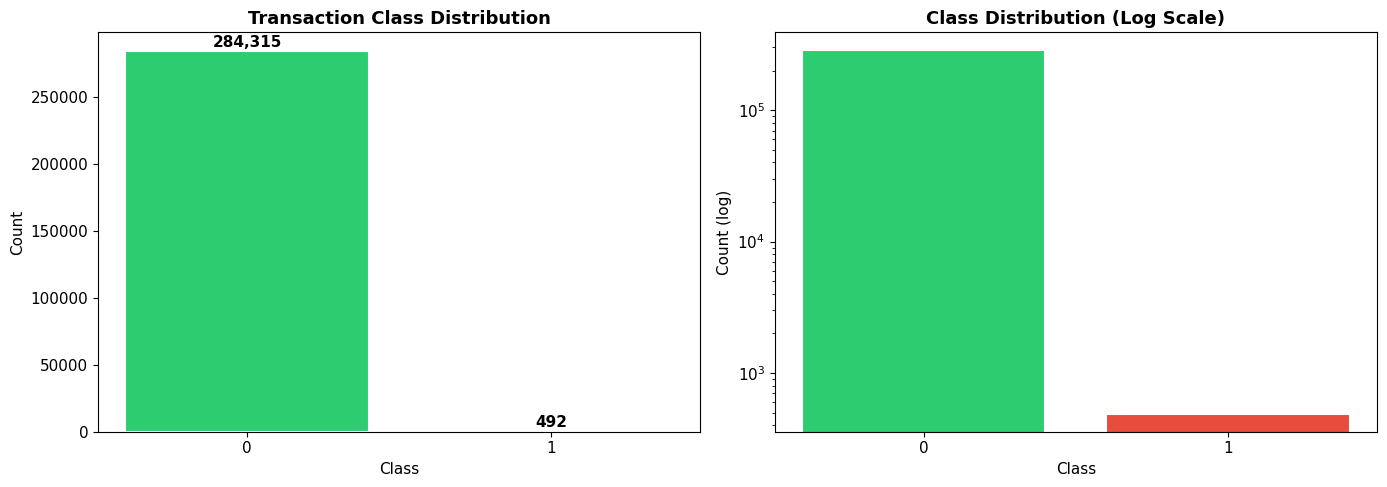


For every 1 fraud transaction, there are ~577 legitimate ones.
This is typical of real payment networks — Visa processes ~150M+ transactions/day with fraud rates of 0.1-0.2%.


In [5]:
# 2.1 Class imbalance visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar([str(majority_class), str(minority_class)],
                    [legit_count, fraud_count],
                    color=COLOR_PALETTE, edgecolor='white', linewidth=1.5)
axes[0].set_title('Transaction Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Class')
for bar, count in zip(bars, [legit_count, fraud_count]):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1000,
                f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Log-scale version to actually see fraud
axes[1].bar([str(majority_class), str(minority_class)],
            [legit_count, fraud_count],
            color=COLOR_PALETTE, edgecolor='white', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set_title('Class Distribution (Log Scale)', fontweight='bold')
axes[1].set_ylabel('Count (log)')
axes[1].set_xlabel('Class')

plt.tight_layout()
plt.show()
print(f"\nFor every 1 fraud transaction, there are ~{legit_count // fraud_count} legitimate ones.")
print("This is typical of real payment networks — Visa processes ~150M+ transactions/day with fraud rates of 0.1-0.2%.")

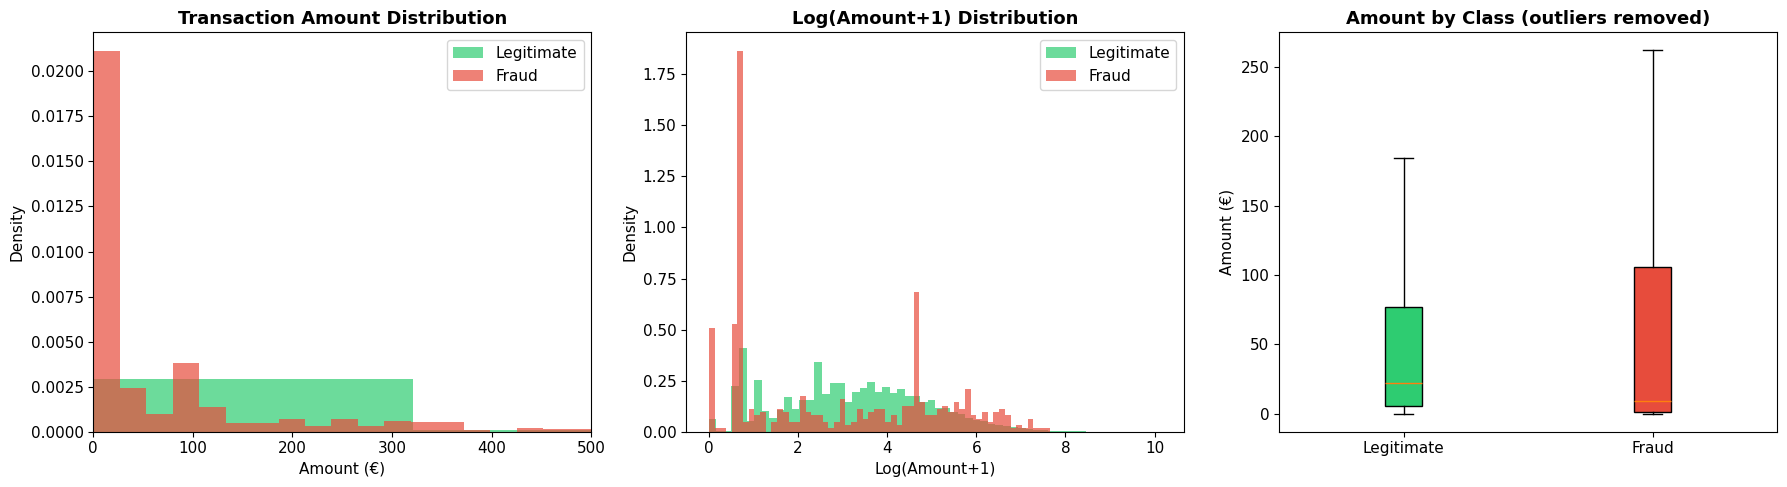


Legitimate — Mean: €88.29, Median: €22.00
Fraud      — Mean: €122.21, Median: €9.25


In [6]:
# 2.2 Transaction Amount analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Amount distribution — legit vs fraud
for cls, color, label in [(majority_class, COLOR_LEGIT, 'Legitimate'),
                           (minority_class, COLOR_FRAUD, 'Fraud')]:
    subset = df[df[target_col] == cls]['Amount']
    axes[0].hist(subset, bins=80, alpha=0.7, color=color, label=label, density=True)
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Density')
axes[0].set_xlim(0, 500)
axes[0].legend()

# Log amount
for cls, color, label in [(majority_class, COLOR_LEGIT, 'Legitimate'),
                           (minority_class, COLOR_FRAUD, 'Fraud')]:
    subset = df[df[target_col] == cls]['Amount']
    log_amt = np.log1p(subset)
    axes[1].hist(log_amt, bins=60, alpha=0.7, color=color, label=label, density=True)
axes[1].set_title('Log(Amount+1) Distribution', fontweight='bold')
axes[1].set_xlabel('Log(Amount+1)')
axes[1].set_ylabel('Density')
axes[1].legend()

# Box plot comparison
fraud_df = df[df[target_col] == minority_class]
legit_df = df[df[target_col] == majority_class]
bp = axes[2].boxplot([legit_df['Amount'], fraud_df['Amount']],
                      labels=['Legitimate', 'Fraud'],
                      patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor(COLOR_LEGIT)
bp['boxes'][1].set_facecolor(COLOR_FRAUD)
axes[2].set_title('Amount by Class (outliers removed)', fontweight='bold')
axes[2].set_ylabel('Amount (€)')

plt.tight_layout()
plt.show()

print(f"\nLegitimate — Mean: €{legit_df['Amount'].mean():.2f}, Median: €{legit_df['Amount'].median():.2f}")
print(f"Fraud      — Mean: €{fraud_df['Amount'].mean():.2f}, Median: €{fraud_df['Amount'].median():.2f}")

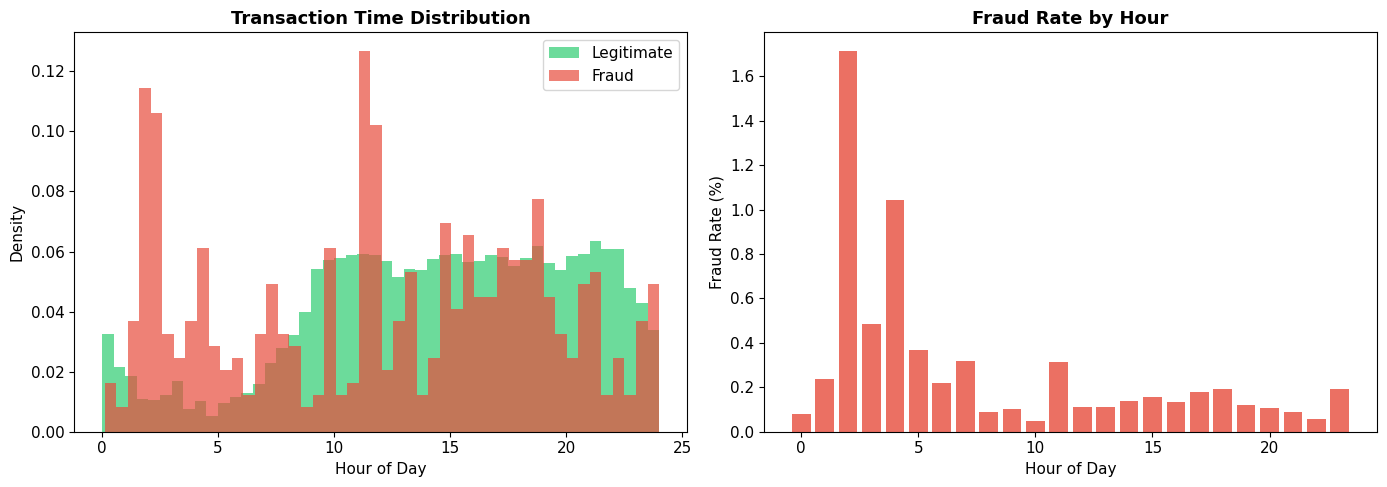

In [7]:
# 2.3 Time analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time distribution (convert to hours)
df['Hour'] = (df['Time'] / 3600) % 24

for cls, color, label in [(majority_class, COLOR_LEGIT, 'Legitimate'),
                           (minority_class, COLOR_FRAUD, 'Fraud')]:
    subset = df[df[target_col] == cls]['Hour']
    axes[0].hist(subset, bins=48, alpha=0.7, color=color, label=label, density=True)
axes[0].set_title('Transaction Time Distribution', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Density')
axes[0].legend()

# Fraud rate by hour
hourly = df.groupby(pd.cut(df['Hour'], bins=24, labels=False)).agg(
    fraud_rate=(target_col, 'mean'),
    count=(target_col, 'count')
).reset_index()
axes[1].bar(hourly['Hour'], hourly['fraud_rate'] * 100, color=COLOR_FRAUD, alpha=0.8)
axes[1].set_title('Fraud Rate by Hour', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

# Drop the temporary Hour column
df.drop('Hour', axis=1, inplace=True)

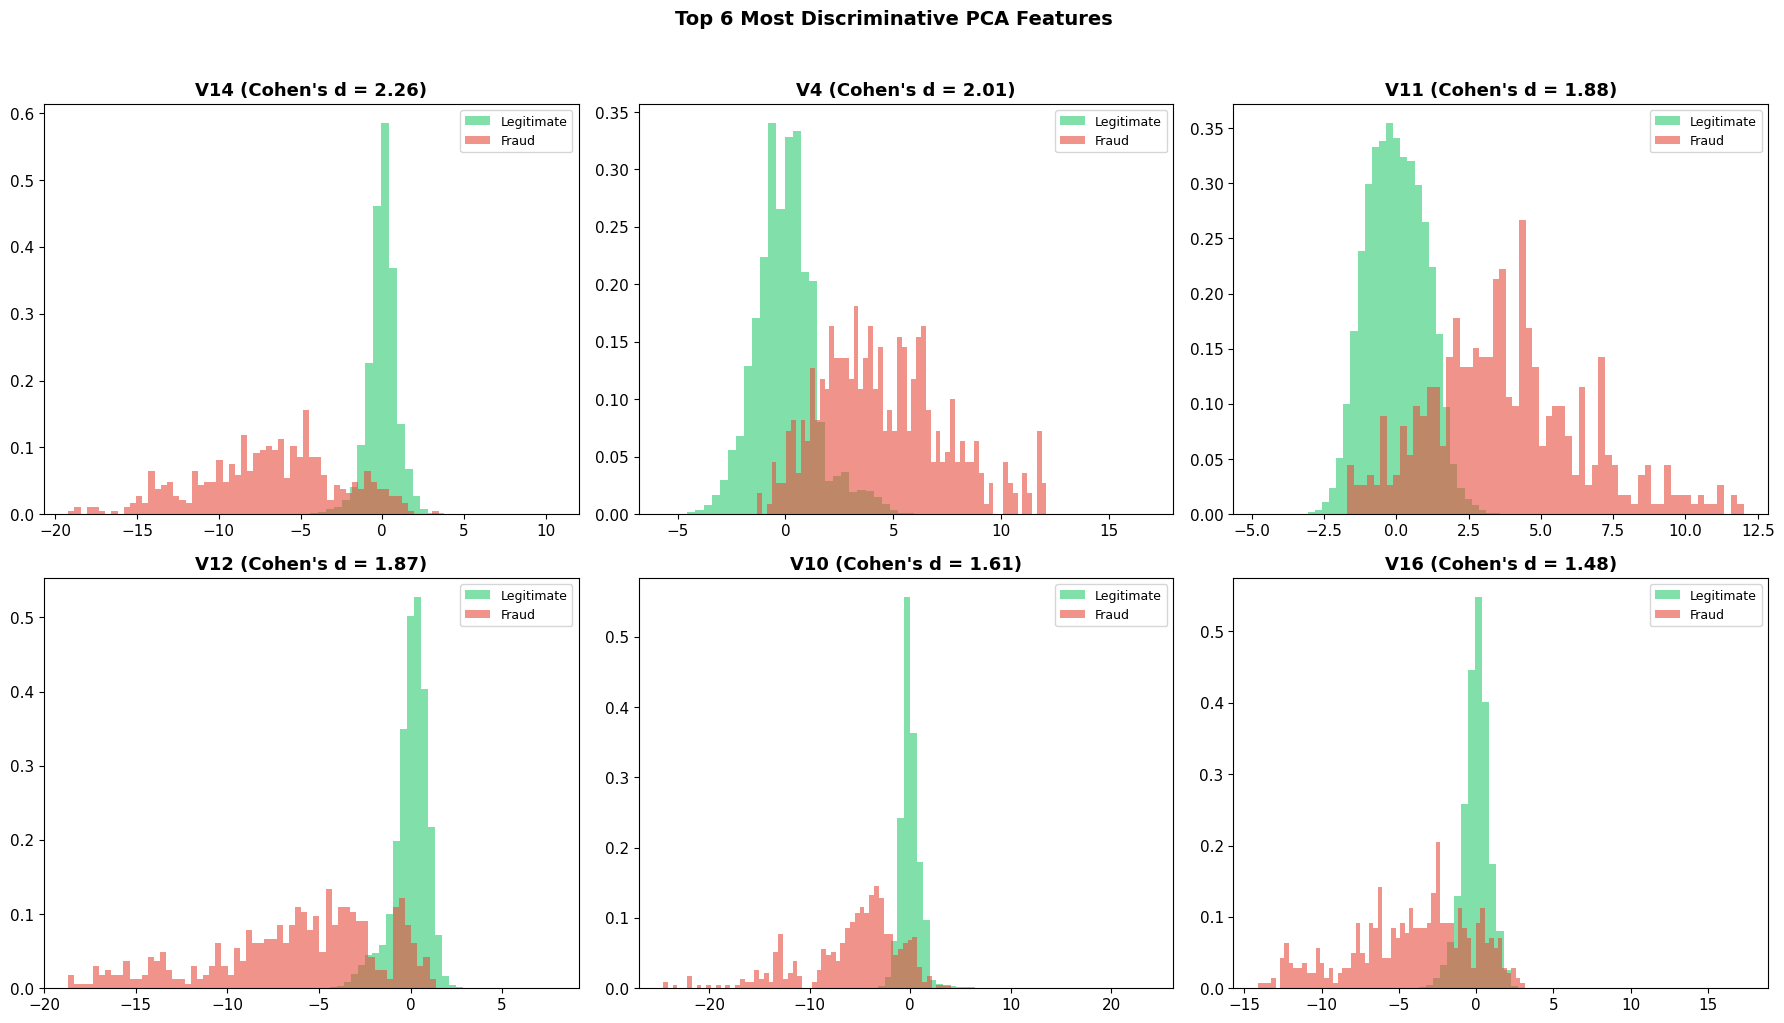

In [8]:
# 2.4 PCA feature distributions — top 6 most discriminative
pca_cols = [c for c in df.columns if c.startswith('V')]

# Calculate mean difference (fraud - legit) for each V feature
feature_separation = {}
for col in pca_cols:
    legit_mean = legit_df[col].mean()
    fraud_mean = fraud_df[col].mean()
    legit_std = legit_df[col].std()
    fraud_std = fraud_df[col].std()
    pooled_std = np.sqrt((legit_std**2 + fraud_std**2) / 2)
    cohens_d = abs(fraud_mean - legit_mean) / pooled_std if pooled_std > 0 else 0
    feature_separation[col] = cohens_d

# Sort by separation
sorted_features = sorted(feature_separation.items(), key=lambda x: x[1], reverse=True)
top_features = [f[0] for f in sorted_features[:6]]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, feat in enumerate(top_features):
    ax = axes[idx // 3][idx % 3]
    for cls, color, label in [(majority_class, COLOR_LEGIT, 'Legitimate'),
                               (minority_class, COLOR_FRAUD, 'Fraud')]:
        subset = df[df[target_col] == cls][feat]
        ax.hist(subset, bins=60, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(f'{feat} (Cohen\'s d = {feature_separation[feat]:.2f})', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Top 6 Most Discriminative PCA Features', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

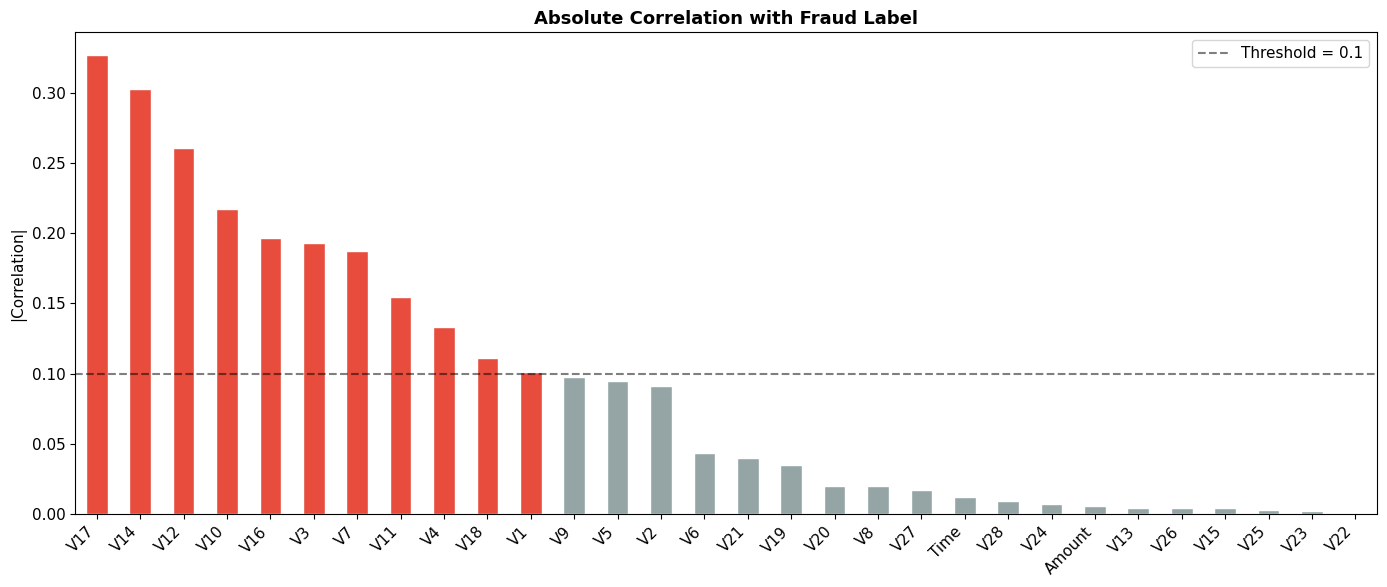


Top 5 correlated features:
  V17: 0.3265
  V14: 0.3025
  V12: 0.2606
  V10: 0.2169
  V16: 0.1965


In [9]:
# 2.5 Correlation with target
correlations = df[pca_cols + ['Amount', 'Time']].corrwith(df[target_col]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = [COLOR_FRAUD if c > 0.1 else '#95a5a6' for c in correlations.values]
correlations.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Absolute Correlation with Fraud Label', fontweight='bold')
ax.set_ylabel('|Correlation|')
ax.axhline(y=0.1, color='black', linestyle='--', alpha=0.5, label='Threshold = 0.1')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTop 5 correlated features:")
for feat, corr in correlations.head(5).items():
    print(f"  {feat}: {corr:.4f}")

---
## 3. Feature Engineering & Preprocessing

The PCA features are already scaled, but `Amount` and `Time` are on their original scales. In a production fraud detection system, feature engineering is where most of the alpha comes from — velocity features, merchant risk scores, geolocation anomalies, device fingerprinting. Here we work with what we have:

- **Scale Amount and Time** to match the PCA feature range
- **Log-transform Amount** — transaction amounts are typically log-normal
- **Interaction features** — combinations of the most discriminative PCA components
- **Stratified sampling** for training efficiency

In [10]:
# 3.1 Feature engineering
df_feat = df.copy()

# Log-transform Amount (highly skewed)
df_feat['Amount_log'] = np.log1p(df_feat['Amount'])

# Scale Amount and Time
scaler_amt = StandardScaler()
scaler_time = StandardScaler()
df_feat['Amount_scaled'] = scaler_amt.fit_transform(df_feat[['Amount']])
df_feat['Time_scaled'] = scaler_time.fit_transform(df_feat[['Time']])
df_feat['Amount_log_scaled'] = StandardScaler().fit_transform(df_feat[['Amount_log']])

# Interaction features from top discriminative PCA components
top_2 = [f[0] for f in sorted_features[:2]]
df_feat['V_interact_01'] = df_feat[top_2[0]] * df_feat[top_2[1]]

top_4 = [f[0] for f in sorted_features[:4]]
df_feat['V_magnitude'] = np.sqrt(sum(df_feat[c]**2 for c in top_4))

# Amount * top PCA feature interaction
df_feat['Amount_V_interact'] = df_feat['Amount_log_scaled'] * df_feat[top_2[0]]

print(f"Original features: {df.shape[1] - 1}")
print(f"Engineered features: {df_feat.shape[1] - 1}")
print(f"New features added: Amount_log, Amount_scaled, Time_scaled, Amount_log_scaled,")
print(f"                    V_interact_01, V_magnitude, Amount_V_interact")

Original features: 30
Engineered features: 37
New features added: Amount_log, Amount_scaled, Time_scaled, Amount_log_scaled,
                    V_interact_01, V_magnitude, Amount_V_interact


In [11]:
# 3.2 Prepare feature matrix — drop raw Amount and Time (using scaled versions)
drop_cols = ['Amount', 'Time', 'Amount_log', target_col]
feature_cols = [c for c in df_feat.columns if c not in drop_cols]

X_full = df_feat[feature_cols].values
y_full = df_feat[target_col].values

print(f"Full dataset: X={X_full.shape}, y={y_full.shape}")
print(f"Fraud rate: {y_full.mean()*100:.4f}%")
print(f"\nFeatures ({len(feature_cols)}):")
for i, col in enumerate(feature_cols):
    print(f"  [{i:2d}] {col}")

Full dataset: X=(284807, 34), y=(284807,)
Fraud rate: 0.1727%

Features (34):
  [ 0] V1
  [ 1] V2
  [ 2] V3
  [ 3] V4
  [ 4] V5
  [ 5] V6
  [ 6] V7
  [ 7] V8
  [ 8] V9
  [ 9] V10
  [10] V11
  [11] V12
  [12] V13
  [13] V14
  [14] V15
  [15] V16
  [16] V17
  [17] V18
  [18] V19
  [19] V20
  [20] V21
  [21] V22
  [22] V23
  [23] V24
  [24] V25
  [25] V26
  [26] V27
  [27] V28
  [28] Amount_scaled
  [29] Time_scaled
  [30] Amount_log_scaled
  [31] V_interact_01
  [32] V_magnitude
  [33] Amount_V_interact


In [12]:
# 3.3 Stratified sampling to 100k rows for training speed
SAMPLE_SIZE = 100_000
np.random.seed(42)

if len(X_full) > SAMPLE_SIZE:
    # Stratified sample — keep ALL fraud, downsample legit
    fraud_idx = np.where(y_full == minority_class)[0]
    legit_idx = np.where(y_full == majority_class)[0]

    n_legit_sample = SAMPLE_SIZE - len(fraud_idx)
    legit_sampled = np.random.choice(legit_idx, size=n_legit_sample, replace=False)

    sample_idx = np.concatenate([fraud_idx, legit_sampled])
    np.random.shuffle(sample_idx)

    X = X_full[sample_idx]
    y = y_full[sample_idx]
    print(f"Sampled: {len(X):,} rows (kept all {len(fraud_idx):,} fraud + {n_legit_sample:,} legit)")
else:
    X = X_full
    y = y_full
    print(f"Dataset small enough, using all {len(X):,} rows")

print(f"Sampled fraud rate: {y.mean()*100:.4f}%")
print(f"Shape: X={X.shape}, y={y.shape}")

Sampled: 100,000 rows (kept all 492 fraud + 99,508 legit)
Sampled fraud rate: 0.4920%
Shape: X=(100000, 34), y=(100000,)


---
## 4. Fraud Pattern Analysis

Before training models, let's understand *what makes fraud transactions different*. This isn't just academic — in production, these patterns inform rule engines that work alongside ML models. Most payment processors use a hybrid approach: simple rules catch obvious fraud instantly, while ML models handle the subtle cases.

We'll use Cohen's d (effect size) to quantify how different each feature's distribution is between fraud and legitimate transactions.

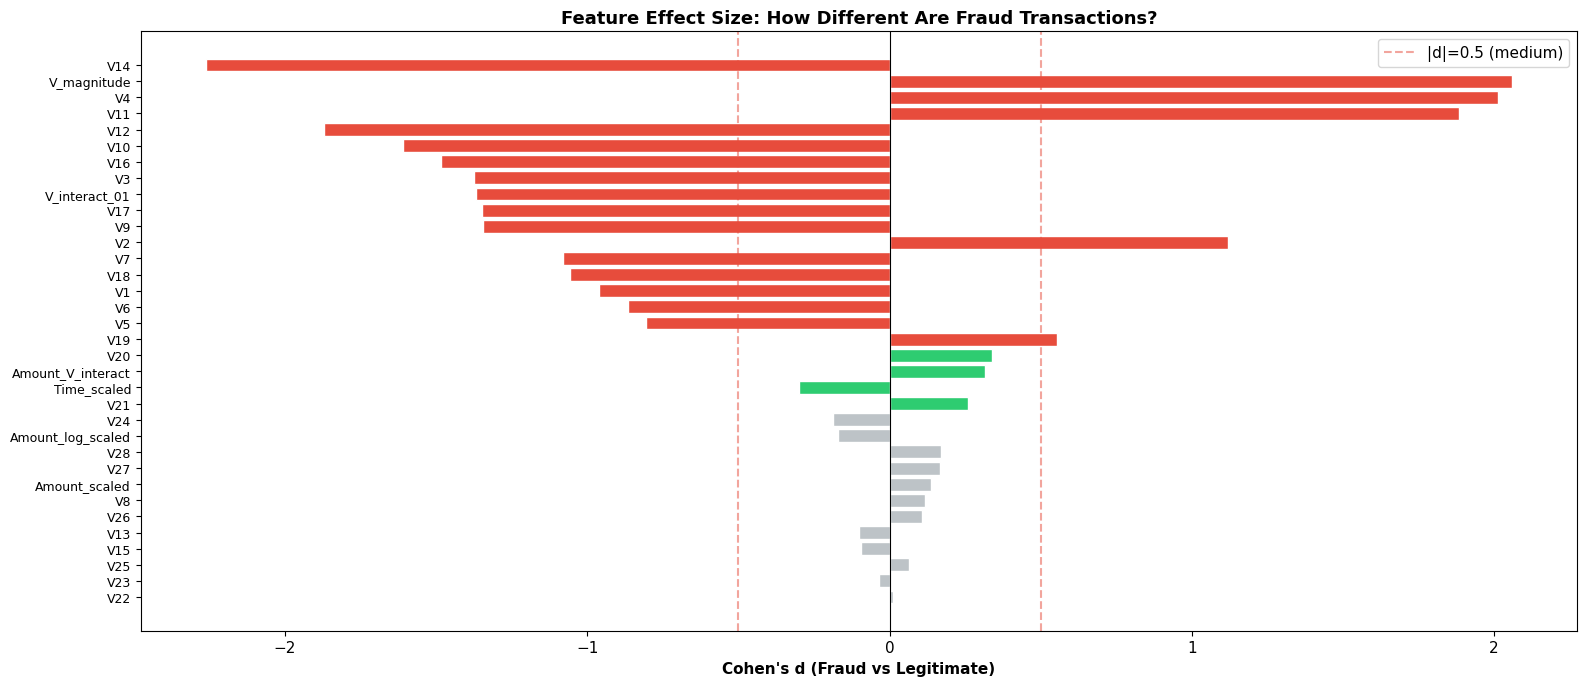


Top 10 most discriminative features (by |Cohen's d|):
---------------------------------------------
  V14                   d = -2.261  (fraud LOWER)
  V_magnitude           d = +2.058  (fraud HIGHER)
  V4                    d = +2.014  (fraud HIGHER)
  V11                   d = +1.885  (fraud HIGHER)
  V12                   d = -1.869  (fraud LOWER)
  V10                   d = -1.608  (fraud LOWER)
  V16                   d = -1.484  (fraud LOWER)
  V3                    d = -1.374  (fraud LOWER)
  V_interact_01         d = -1.369  (fraud LOWER)
  V17                   d = -1.349  (fraud LOWER)


In [13]:
# 4.1 Cohen's d for all features — statistical separation analysis
cohens_d_results = {}
for i, col in enumerate(feature_cols):
    legit_vals = X[y == majority_class, i]
    fraud_vals = X[y == minority_class, i]
    
    legit_mean, fraud_mean = legit_vals.mean(), fraud_vals.mean()
    pooled_std = np.sqrt((legit_vals.std()**2 + fraud_vals.std()**2) / 2)
    d = (fraud_mean - legit_mean) / pooled_std if pooled_std > 0 else 0
    cohens_d_results[col] = d

# Sort by absolute effect size
sorted_effects = sorted(cohens_d_results.items(), key=lambda x: abs(x[1]), reverse=True)

fig, ax = plt.subplots(figsize=(16, 7))
features_sorted = [x[0] for x in sorted_effects]
effects_sorted = [x[1] for x in sorted_effects]
colors = [COLOR_FRAUD if abs(d) > 0.5 else COLOR_LEGIT if abs(d) > 0.2 else '#bdc3c7' 
          for d in effects_sorted]

ax.barh(range(len(features_sorted)), effects_sorted, color=colors, edgecolor='white')
ax.set_yticks(range(len(features_sorted)))
ax.set_yticklabels(features_sorted, fontsize=9)
ax.set_xlabel("Cohen's d (Fraud vs Legitimate)", fontweight='bold')
ax.set_title("Feature Effect Size: How Different Are Fraud Transactions?", fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.axvline(x=0.5, color=COLOR_FRAUD, linestyle='--', alpha=0.5, label='|d|=0.5 (medium)')
ax.axvline(x=-0.5, color=COLOR_FRAUD, linestyle='--', alpha=0.5)
ax.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most discriminative features (by |Cohen's d|):")
print("-" * 45)
for feat, d in sorted_effects[:10]:
    direction = "fraud HIGHER" if d > 0 else "fraud LOWER"
    print(f"  {feat:20s}  d = {d:+.3f}  ({direction})")

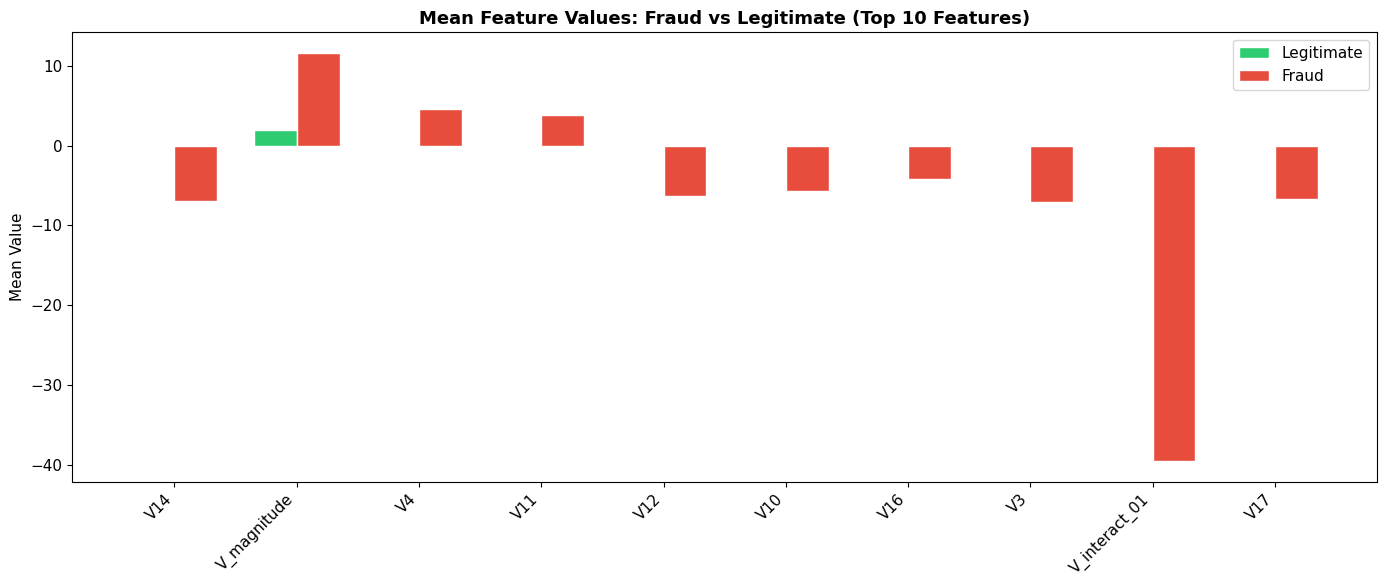


Key fraud signatures (production rule candidates):
  V14: Fraud mean = -6.972 vs Legit mean = 0.011
  V_magnitude: Fraud mean = 11.611 vs Legit mean = 1.926
  V4: Fraud mean = 4.542 vs Legit mean = -0.004
  V11: Fraud mean = 3.800 vs Legit mean = -0.009
  V12: Fraud mean = -6.259 vs Legit mean = 0.011


In [14]:
# 4.2 Fraud vs Legitimate profile — mean feature values
top_10_feats = [x[0] for x in sorted_effects[:10]]
top_10_idx = [feature_cols.index(f) for f in top_10_feats]

fig, ax = plt.subplots(figsize=(14, 6))
x_pos = np.arange(len(top_10_feats))
width = 0.35

legit_means = [X[y == majority_class, i].mean() for i in top_10_idx]
fraud_means = [X[y == minority_class, i].mean() for i in top_10_idx]

ax.bar(x_pos - width/2, legit_means, width, color=COLOR_LEGIT, label='Legitimate', edgecolor='white')
ax.bar(x_pos + width/2, fraud_means, width, color=COLOR_FRAUD, label='Fraud', edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(top_10_feats, rotation=45, ha='right')
ax.set_title('Mean Feature Values: Fraud vs Legitimate (Top 10 Features)', fontweight='bold')
ax.set_ylabel('Mean Value')
ax.legend()
plt.tight_layout()
plt.show()

print("\nKey fraud signatures (production rule candidates):")
for feat, d in sorted_effects[:5]:
    fi = feature_cols.index(feat)
    fraud_mean = X[y == minority_class, fi].mean()
    legit_mean = X[y == majority_class, fi].mean()
    print(f"  {feat}: Fraud mean = {fraud_mean:.3f} vs Legit mean = {legit_mean:.3f}")

---
## 5. Model Training & Comparison

We train four models with increasing complexity:
1. **Logistic Regression** — baseline, interpretable, fast inference (<1ms)
2. **Random Forest** — non-linear, handles interactions, moderate inference time
3. **XGBoost** — gradient boosting with `scale_pos_weight` for imbalance
4. **LightGBM** — fastest gradient boosting, production-friendly

All use **3-fold stratified CV** with OOF (out-of-fold) predictions. We focus on:
- **PR-AUC** (average precision) — the primary metric for imbalanced fraud detection
- **ROC-AUC** — standard but can be misleading with extreme imbalance
- **Recall** — how many frauds we actually catch
- **Precision** — how many flagged transactions are truly fraud

In [15]:
# 5.1 Model definitions with class imbalance handling
n_fraud = (y == minority_class).sum()
n_legit = (y == majority_class).sum()
scale_ratio = n_legit / n_fraud

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42,
        n_jobs=-1, max_depth=12, min_samples_leaf=5
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100, scale_pos_weight=scale_ratio,
        random_state=42, eval_metric='logloss',
        max_depth=6, learning_rate=0.1, n_jobs=-1, verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100, class_weight='balanced',
        random_state=42, max_depth=-1, learning_rate=0.05,
        n_jobs=-1, verbose=-1, num_leaves=31, min_child_samples=5,
        reg_alpha=0.1, reg_lambda=1.0
    )
}

print(f"Class imbalance ratio: 1:{scale_ratio:.0f} (used for scale_pos_weight)")
print(f"Training samples: {len(X):,}")
print(f"Features: {X.shape[1]}")
print(f"CV strategy: 3-fold StratifiedKFold")
print(f"\nModels to train:")
for name in models:
    print(f"  - {name}")

Class imbalance ratio: 1:202 (used for scale_pos_weight)
Training samples: 100,000
Features: 34
CV strategy: 3-fold StratifiedKFold

Models to train:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - LightGBM


In [16]:
# 5.2 Manual 3-fold CV with OOF predictions
import time

N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

results = {}
oof_preds = {}
oof_probs = {}

for model_name, model_template in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    oof_pred = np.zeros(len(y), dtype=int)
    oof_prob = np.zeros(len(y), dtype=float)
    fold_metrics = []
    start_time = time.time()
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        # Clone model for each fold
        from sklearn.base import clone
        model = clone(model_template)
        model.fit(X_train, y_train)
        
        # Predictions
        pred = model.predict(X_val)
        prob = model.predict_proba(X_val)[:, 1]
        
        oof_pred[val_idx] = pred
        oof_prob[val_idx] = prob
        
        # Fold metrics
        fold_f1 = f1_score(y_val, pred)
        fold_prauc = average_precision_score(y_val, prob)
        fold_rocauc = roc_auc_score(y_val, prob)
        fold_recall = recall_score(y_val, pred)
        fold_precision = precision_score(y_val, pred)
        
        print(f"  Fold {fold+1}: F1={fold_f1:.4f} | PR-AUC={fold_prauc:.4f} | "
              f"ROC-AUC={fold_rocauc:.4f} | Recall={fold_recall:.4f} | Prec={fold_precision:.4f}")
        
        fold_metrics.append({
            'f1': fold_f1, 'pr_auc': fold_prauc, 'roc_auc': fold_rocauc,
            'recall': fold_recall, 'precision': fold_precision
        })
    
    elapsed = time.time() - start_time
    
    # OOF aggregate metrics
    oof_results = {
        'accuracy': accuracy_score(y, oof_pred),
        'precision': precision_score(y, oof_pred),
        'recall': recall_score(y, oof_pred),
        'f1': f1_score(y, oof_pred),
        'roc_auc': roc_auc_score(y, oof_prob),
        'pr_auc': average_precision_score(y, oof_prob),
        'brier': brier_score_loss(y, oof_prob),
        'time': elapsed,
        'fold_metrics': fold_metrics
    }
    
    results[model_name] = oof_results
    oof_preds[model_name] = oof_pred
    oof_probs[model_name] = oof_prob
    
    print(f"\n  OOF: F1={oof_results['f1']:.4f} | PR-AUC={oof_results['pr_auc']:.4f} | "
          f"ROC-AUC={oof_results['roc_auc']:.4f} | Time={elapsed:.1f}s")


Training: Logistic Regression
  Fold 1: F1=0.2498 | PR-AUC=0.8229 | ROC-AUC=0.9821 | Recall=0.9024 | Prec=0.1450
  Fold 2: F1=0.2580 | PR-AUC=0.8238 | ROC-AUC=0.9788 | Recall=0.9085 | Prec=0.1504
  Fold 3: F1=0.2564 | PR-AUC=0.8301 | ROC-AUC=0.9729 | Recall=0.9207 | Prec=0.1489

  OOF: F1=0.2547 | PR-AUC=0.8240 | ROC-AUC=0.9775 | Time=4.7s

Training: Random Forest
  Fold 1: F1=0.8782 | PR-AUC=0.8575 | ROC-AUC=0.9793 | Recall=0.8354 | Prec=0.9257
  Fold 2: F1=0.8839 | PR-AUC=0.8577 | ROC-AUC=0.9822 | Recall=0.8354 | Prec=0.9384
  Fold 3: F1=0.8766 | PR-AUC=0.8571 | ROC-AUC=0.9718 | Recall=0.8232 | Prec=0.9375

  OOF: F1=0.8796 | PR-AUC=0.8552 | ROC-AUC=0.9773 | Time=51.1s

Training: XGBoost
  Fold 1: F1=0.8754 | PR-AUC=0.8536 | ROC-AUC=0.9728 | Recall=0.8354 | Prec=0.9195
  Fold 2: F1=0.8790 | PR-AUC=0.8695 | ROC-AUC=0.9770 | Recall=0.8415 | Prec=0.9200
  Fold 3: F1=0.8690 | PR-AUC=0.8621 | ROC-AUC=0.9814 | Recall=0.8293 | Prec=0.9128

  OOF: F1=0.8745 | PR-AUC=0.8603 | ROC-AUC=0.9762 

In [17]:
# 5.3 Results comparison table
print("\n" + "=" * 90)
print("MODEL COMPARISON (OOF Results)")
print("=" * 90)
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9} {'PR-AUC':>9} {'Brier':>8} {'Time':>7}")
print("-" * 90)

for name, res in results.items():
    print(f"{name:<22} {res['accuracy']:>9.4f} {res['precision']:>10.4f} {res['recall']:>8.4f} "
          f"{res['f1']:>8.4f} {res['roc_auc']:>9.4f} {res['pr_auc']:>9.4f} {res['brier']:>8.4f} {res['time']:>6.1f}s")

best_model = max(results.items(), key=lambda x: x[1]['pr_auc'])
print(f"\nBest model by PR-AUC: {best_model[0]} ({best_model[1]['pr_auc']:.4f})")
print(f"\nNote: PR-AUC is the primary metric. ROC-AUC can be misleadingly high with extreme imbalance.")


MODEL COMPARISON (OOF Results)
Model                   Accuracy  Precision   Recall       F1   ROC-AUC    PR-AUC    Brier    Time
------------------------------------------------------------------------------------------
Logistic Regression       0.9738     0.1481   0.9106   0.2547    0.9775    0.8240   0.0238    4.7s
Random Forest             0.9989     0.9338   0.8313   0.8796    0.9773    0.8552   0.0012   51.1s
XGBoost                   0.9988     0.9174   0.8354   0.8745    0.9762    0.8603   0.0012    3.8s
LightGBM                  0.9980     0.7660   0.8516   0.8065    0.9726    0.8382   0.0019    4.1s

Best model by PR-AUC: XGBoost (0.8603)

Note: PR-AUC is the primary metric. ROC-AUC can be misleadingly high with extreme imbalance.


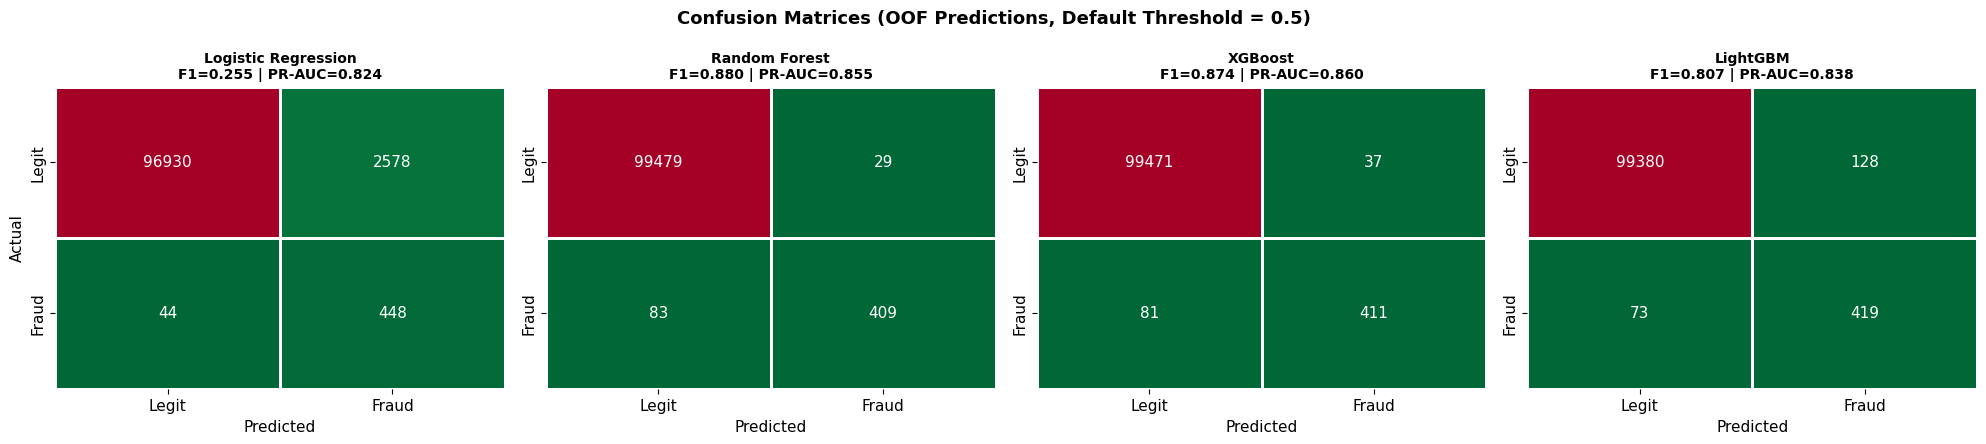

In [18]:
# 5.4 Confusion matrices — all 4 models
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for idx, (name, pred) in enumerate(oof_preds.items()):
    cm = confusion_matrix(y, pred)
    
    # Normalize for display
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[idx],
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'],
                cbar=False, linewidths=1, linecolor='white')
    axes[idx].set_title(f'{name}\nF1={results[name]["f1"]:.3f} | PR-AUC={results[name]["pr_auc"]:.3f}',
                        fontweight='bold', fontsize=10)
    axes[idx].set_ylabel('Actual' if idx == 0 else '')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices (OOF Predictions, Default Threshold = 0.5)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

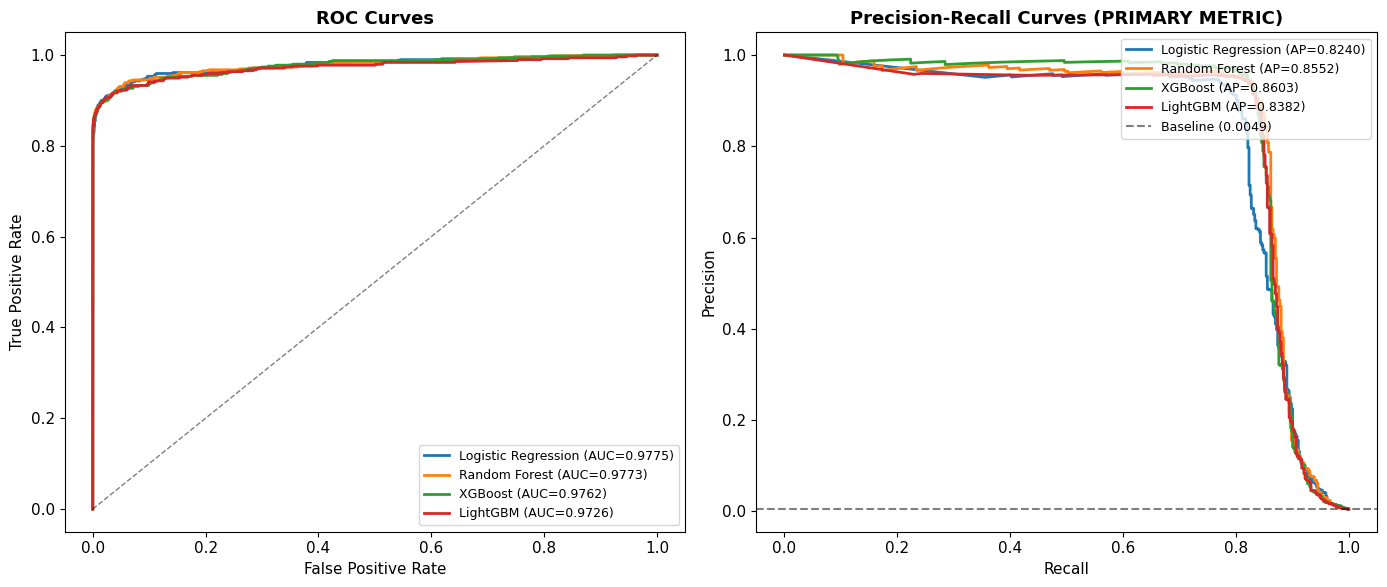


Why PR-AUC matters more than ROC-AUC for fraud detection:
  ROC-AUC uses FPR (FP/total_negatives) — with 99.8% negatives, FPR stays low even with many FP
  PR-AUC uses Precision (TP/(TP+FP)) — directly penalizes false alarms
  A model with ROC-AUC=0.98 might still flag 1000 false positives per real fraud caught


In [19]:
# 5.5 ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, prob in oof_probs.items():
    # ROC curve
    fpr, tpr, _ = roc_curve(y, prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.4f})", linewidth=2)
    
    # PR curve
    prec, rec, _ = precision_recall_curve(y, prob)
    axes[1].plot(rec, prec, label=f"{name} (AP={results[name]['pr_auc']:.4f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1)
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9, loc='lower right')

baseline_rate = y.mean()
axes[1].axhline(y=baseline_rate, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_rate:.4f})')
axes[1].set_title('Precision-Recall Curves (PRIMARY METRIC)', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

print("\nWhy PR-AUC matters more than ROC-AUC for fraud detection:")
print("  ROC-AUC uses FPR (FP/total_negatives) — with 99.8% negatives, FPR stays low even with many FP")
print("  PR-AUC uses Precision (TP/(TP+FP)) — directly penalizes false alarms")
print("  A model with ROC-AUC=0.98 might still flag 1000 false positives per real fraud caught")

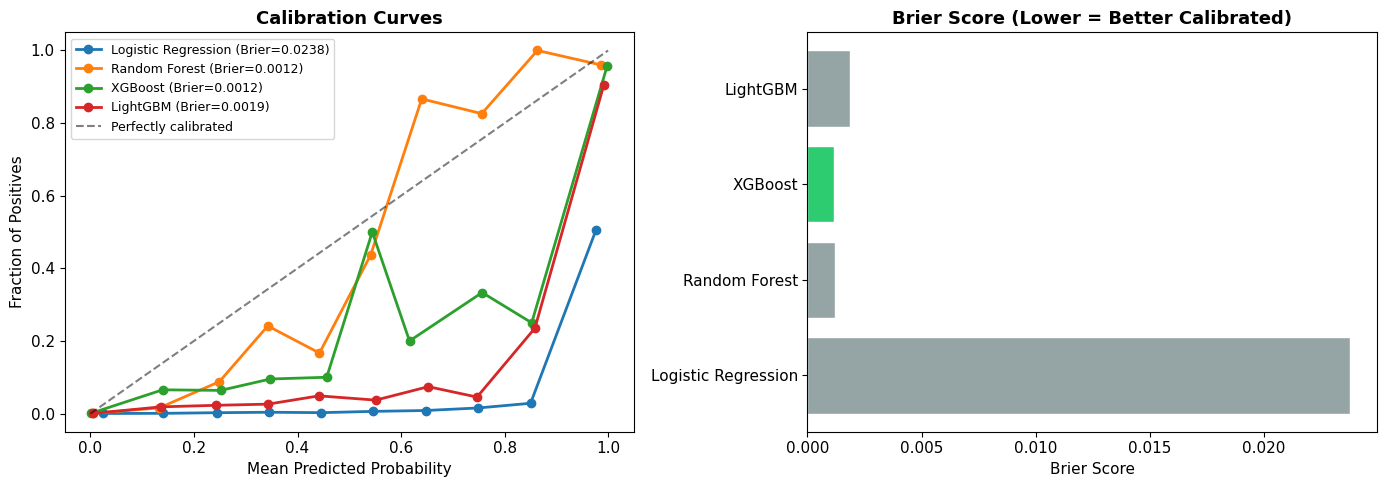


Calibration matters in production: a predicted probability of 0.8 should mean
~80% of those transactions are truly fraud. Poor calibration leads to bad threshold decisions.


In [20]:
# 5.6 Calibration curves & Brier scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, prob in oof_probs.items():
    prob_true, prob_pred = calibration_curve(y, prob, n_bins=10, strategy='uniform')
    axes[0].plot(prob_pred, prob_true, marker='o', label=f"{name} (Brier={results[name]['brier']:.4f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly calibrated')
axes[0].set_title('Calibration Curves', fontweight='bold')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].legend(fontsize=9)

# Brier score comparison
names = list(results.keys())
brier_scores = [results[n]['brier'] for n in names]
colors_brier = [COLOR_LEGIT if b == min(brier_scores) else '#95a5a6' for b in brier_scores]
axes[1].barh(names, brier_scores, color=colors_brier, edgecolor='white')
axes[1].set_title('Brier Score (Lower = Better Calibrated)', fontweight='bold')
axes[1].set_xlabel('Brier Score')

plt.tight_layout()
plt.show()

print("\nCalibration matters in production: a predicted probability of 0.8 should mean")
print("~80% of those transactions are truly fraud. Poor calibration leads to bad threshold decisions.")

---
## 6. Threshold Tuning & Cost-Sensitive Analysis

The default 0.5 threshold is almost never optimal for fraud detection. The right threshold depends on your business context:

| Context | Priority | Typical Threshold |
|---------|----------|-------------------|
| **Conservative bank** | Minimize false positives (customer friction) | Higher threshold (0.6–0.8) |
| **Aggressive fintech** | Maximize fraud catch rate | Lower threshold (0.1–0.3) |
| **Regulatory compliance** | Meet minimum recall requirements | Tuned to recall ≥ 0.80 |

The real question is: **what's the cost of a missed fraud vs. the cost of a false alarm?**

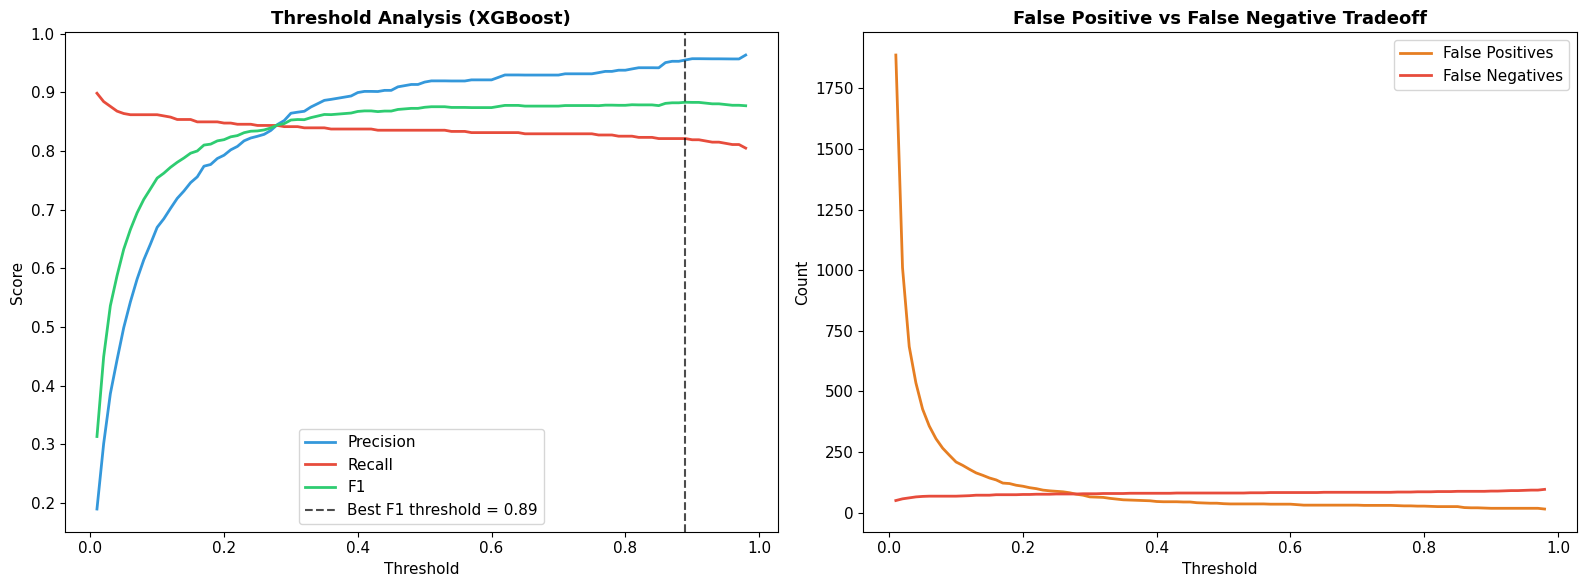


Optimal F1 threshold: 0.89
At this threshold: Precision=0.9551, Recall=0.8211, F1=0.8831


In [21]:
# 6.1 Threshold analysis for best model
best_name = best_model[0]
best_prob = oof_probs[best_name]

thresholds = np.arange(0.01, 0.99, 0.01)
threshold_results = []

for thresh in thresholds:
    pred_t = (best_prob >= thresh).astype(int)
    tp = ((pred_t == 1) & (y == minority_class)).sum()
    fp = ((pred_t == 1) & (y == majority_class)).sum()
    fn = ((pred_t == 0) & (y == minority_class)).sum()
    tn = ((pred_t == 0) & (y == majority_class)).sum()
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    threshold_results.append({
        'threshold': thresh, 'precision': prec, 'recall': rec, 'f1': f1,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
    })

thr_df = pd.DataFrame(threshold_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Precision / Recall / F1 vs threshold
axes[0].plot(thr_df['threshold'], thr_df['precision'], color='#3498db', label='Precision', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['recall'], color=COLOR_FRAUD, label='Recall', linewidth=2)
axes[0].plot(thr_df['threshold'], thr_df['f1'], color=COLOR_LEGIT, label='F1', linewidth=2)
best_f1_idx = thr_df['f1'].idxmax()
best_f1_thresh = thr_df.loc[best_f1_idx, 'threshold']
axes[0].axvline(x=best_f1_thresh, color='black', linestyle='--', alpha=0.7, 
                label=f'Best F1 threshold = {best_f1_thresh:.2f}')
axes[0].set_title(f'Threshold Analysis ({best_name})', fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()

# FP vs FN tradeoff
axes[1].plot(thr_df['threshold'], thr_df['fp'], color='#e67e22', label='False Positives', linewidth=2)
axes[1].plot(thr_df['threshold'], thr_df['fn'], color=COLOR_FRAUD, label='False Negatives', linewidth=2)
axes[1].set_title('False Positive vs False Negative Tradeoff', fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nOptimal F1 threshold: {best_f1_thresh:.2f}")
print(f"At this threshold: Precision={thr_df.loc[best_f1_idx, 'precision']:.4f}, "
      f"Recall={thr_df.loc[best_f1_idx, 'recall']:.4f}, F1={thr_df.loc[best_f1_idx, 'f1']:.4f}")

In [22]:
# 6.2 Business scenario analysis — dollar impact
AVG_FRAUD_AMOUNT = fraud_df['Amount'].mean()
AVG_LEGIT_AMOUNT = legit_df['Amount'].mean()

# Cost assumptions (typical for card-not-present transactions)
COST_FN = AVG_FRAUD_AMOUNT * 1.5   # Chargeback + fees + investigation
COST_FP = 2.50                      # Customer friction cost (support call, lost sale probability)
COST_TP = 0.50                      # Cost of correctly blocking (verification SMS, etc.)

scenarios = {
    'Conservative Bank (thresh=0.7)': 0.70,
    'Balanced (Best F1)': best_f1_thresh,
    'Aggressive Fintech (thresh=0.15)': 0.15,
    'Maximum Recall (thresh=0.05)': 0.05,
}

print("=" * 90)
print("BUSINESS SCENARIO ANALYSIS")
print(f"Cost assumptions: FN (missed fraud)=€{COST_FN:.2f}, FP (false alarm)=€{COST_FP:.2f}")
print("=" * 90)
print(f"\n{'Scenario':<38} {'Thresh':>7} {'Recall':>8} {'Prec':>8} {'FP':>7} {'FN':>5} {'Est. Cost':>12}")
print("-" * 90)

for scenario_name, thresh in scenarios.items():
    row = thr_df.iloc[(thr_df['threshold'] - thresh).abs().argsort()[:1]].iloc[0]
    total_cost = row['fn'] * COST_FN + row['fp'] * COST_FP + row['tp'] * COST_TP
    print(f"{scenario_name:<38} {thresh:>7.2f} {row['recall']:>8.4f} {row['precision']:>8.4f} "
          f"{int(row['fp']):>7,} {int(row['fn']):>5,} €{total_cost:>10,.2f}")

print(f"\nKey insight: The 'best' threshold depends entirely on your business context.")
print(f"A bank prioritizes precision (fewer false alarms), a fintech prioritizes recall (catch more fraud).")

BUSINESS SCENARIO ANALYSIS
Cost assumptions: FN (missed fraud)=€183.32, FP (false alarm)=€2.50

Scenario                                Thresh   Recall     Prec      FP    FN    Est. Cost
------------------------------------------------------------------------------------------
Conservative Bank (thresh=0.7)            0.70   0.8293   0.9294      31    84 € 15,680.13
Balanced (Best F1)                        0.89   0.8211   0.9551      19    88 € 16,381.39
Aggressive Fintech (thresh=0.15)          0.15   0.8537   0.7460     143    72 € 13,766.32
Maximum Recall (thresh=0.05)              0.05   0.8638   0.4988     427    67 € 13,562.24

Key insight: The 'best' threshold depends entirely on your business context.
A bank prioritizes precision (fewer false alarms), a fintech prioritizes recall (catch more fraud).


---
## 7. Model Interpretability

Regulators (AUSTRAC, APRA) increasingly require *explainable* fraud detection. You can't just flag a transaction — you need to say *why*. This section examines:

- Feature importance consensus across all four models
- Logistic Regression coefficients (the most transparent model)
- Which PCA components drive fraud detection the most

In [23]:
# 7.1 Feature importance — train final models on full sample for importance extraction
importances = {}

# Logistic Regression — coefficients
lr_final = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
lr_final.fit(X, y)
importances['Logistic Regression'] = np.abs(lr_final.coef_[0])

# Random Forest — feature importances
rf_final = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, 
                                   n_jobs=-1, max_depth=12, min_samples_leaf=5)
rf_final.fit(X, y)
importances['Random Forest'] = rf_final.feature_importances_

# XGBoost
xgb_final = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=scale_ratio,
                                random_state=42, eval_metric='logloss',
                                max_depth=6, learning_rate=0.1, n_jobs=-1, verbosity=0)
xgb_final.fit(X, y)
importances['XGBoost'] = xgb_final.feature_importances_

# LightGBM
lgb_final = lgb.LGBMClassifier(n_estimators=100, class_weight='balanced',
                                 random_state=42, max_depth=-1, learning_rate=0.05,
                                 n_jobs=-1, verbose=-1, num_leaves=31, min_child_samples=5,
                                 reg_alpha=0.1, reg_lambda=1.0)
lgb_final.fit(X, y)
importances['LightGBM'] = lgb_final.feature_importances_

print("Feature importances extracted from all 4 models.")

Feature importances extracted from all 4 models.


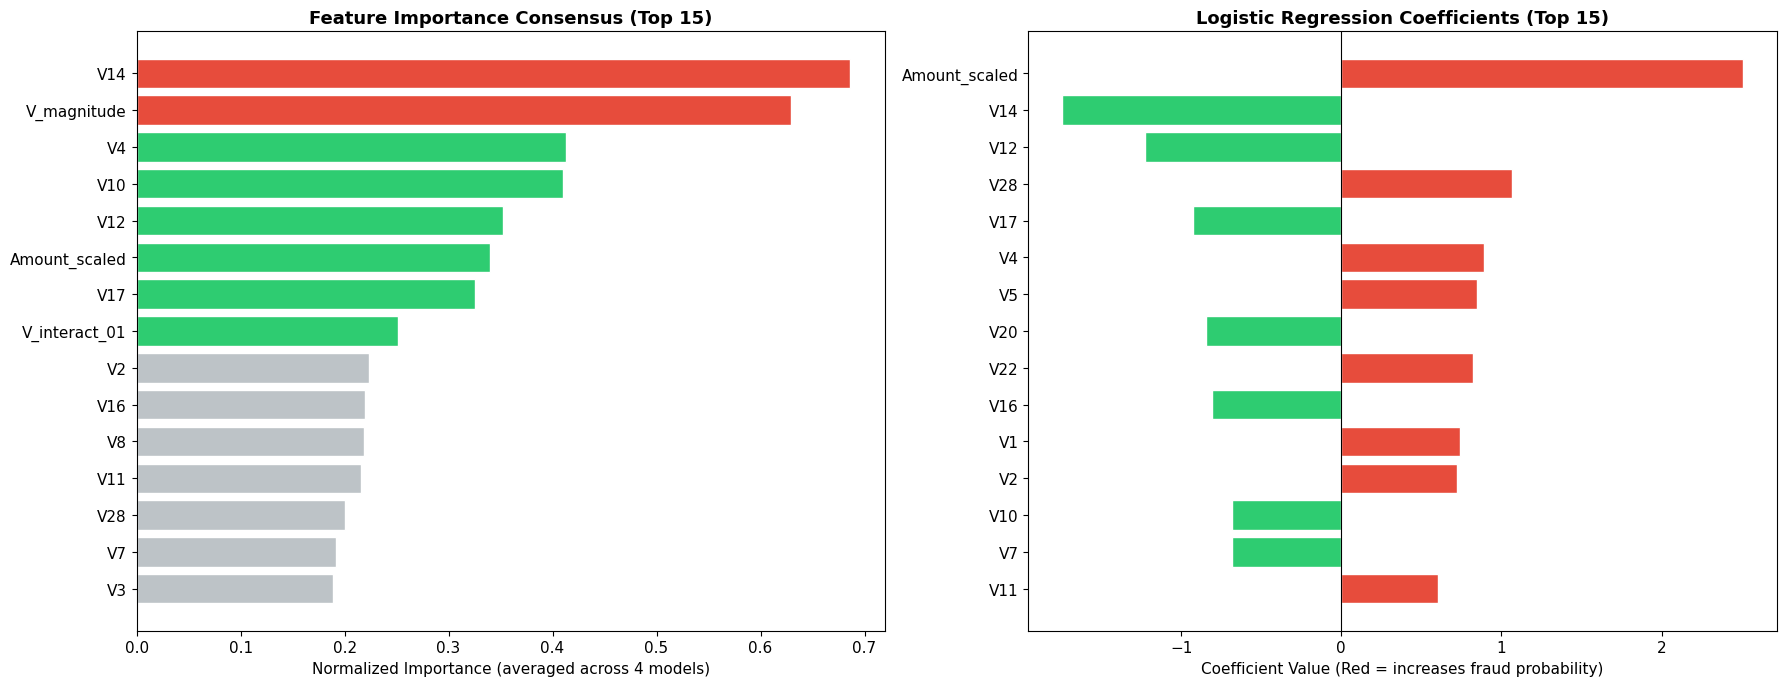


Interpretability summary:
  Top 3 features (consensus): V14, V_magnitude, V4
  These features drive the model's fraud detection across all architectures.

  In production, this maps to the question: 'Why was this transaction flagged?'
  The answer: 'V14 and V_magnitude were anomalous.'


In [24]:
# 7.2 Importance consensus — normalized and averaged
# Normalize each model's importances to [0, 1]
norm_importances = {}
for name, imp in importances.items():
    imp_max = imp.max()
    norm_importances[name] = imp / imp_max if imp_max > 0 else imp

# Average across models
avg_importance = np.mean([norm_importances[m] for m in norm_importances], axis=0)
sorted_idx = np.argsort(avg_importance)[::-1][:15]  # Top 15

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Consensus importance
top_features_names = [feature_cols[i] for i in sorted_idx]
top_features_vals = avg_importance[sorted_idx]
colors_imp = [COLOR_FRAUD if v > 0.5 else COLOR_LEGIT if v > 0.25 else '#bdc3c7' for v in top_features_vals]

axes[0].barh(range(len(top_features_names)), top_features_vals, color=colors_imp, edgecolor='white')
axes[0].set_yticks(range(len(top_features_names)))
axes[0].set_yticklabels(top_features_names)
axes[0].set_title('Feature Importance Consensus (Top 15)', fontweight='bold')
axes[0].set_xlabel('Normalized Importance (averaged across 4 models)')
axes[0].invert_yaxis()

# LR coefficients (signed)
lr_coefs = lr_final.coef_[0]
lr_sorted_idx = np.argsort(np.abs(lr_coefs))[::-1][:15]
lr_feat_names = [feature_cols[i] for i in lr_sorted_idx]
lr_coef_vals = lr_coefs[lr_sorted_idx]
lr_colors = [COLOR_FRAUD if c > 0 else COLOR_LEGIT for c in lr_coef_vals]

axes[1].barh(range(len(lr_feat_names)), lr_coef_vals, color=lr_colors, edgecolor='white')
axes[1].set_yticks(range(len(lr_feat_names)))
axes[1].set_yticklabels(lr_feat_names)
axes[1].set_title('Logistic Regression Coefficients (Top 15)', fontweight='bold')
axes[1].set_xlabel('Coefficient Value (Red = increases fraud probability)')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nInterpretability summary:")
print(f"  Top 3 features (consensus): {', '.join(top_features_names[:3])}")
print(f"  These features drive the model's fraud detection across all architectures.")
print(f"\n  In production, this maps to the question: 'Why was this transaction flagged?'")
print(f"  The answer: '{top_features_names[0]} and {top_features_names[1]} were anomalous.'")

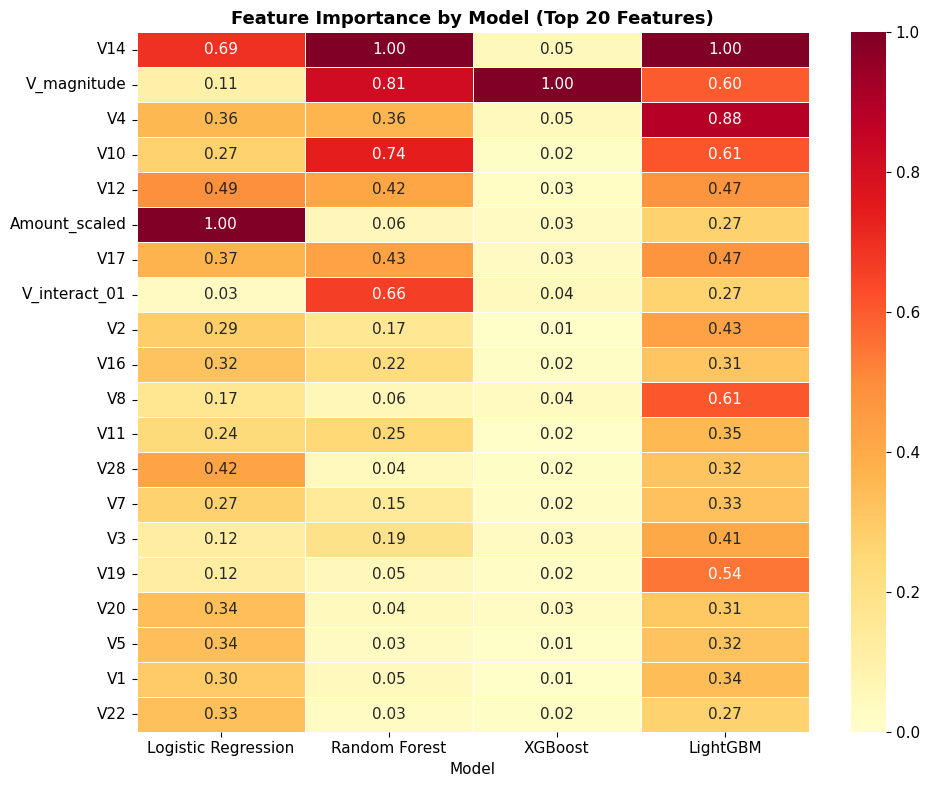


Consensus features (important across ALL models) are the most reliable for production.
Features that only matter to one model may be capturing noise or artefacts.


In [25]:
# 7.3 Per-model importance heatmap
top_20_idx = np.argsort(avg_importance)[::-1][:20]
top_20_names = [feature_cols[i] for i in top_20_idx]

heatmap_data = pd.DataFrame({
    name: [norm_importances[name][i] for i in top_20_idx]
    for name in norm_importances
}, index=top_20_names)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
ax.set_title('Feature Importance by Model (Top 20 Features)', fontweight='bold')
ax.set_xlabel('Model')
plt.tight_layout()
plt.show()

print("\nConsensus features (important across ALL models) are the most reliable for production.")
print("Features that only matter to one model may be capturing noise or artefacts.")

---
## 8. Production Deployment Considerations

Building a model is the easy part. Deploying fraud detection in a live payment system involves architecture, latency, compliance, and monitoring challenges that dwarf the ML work.

### Real-Time Transaction Scoring Architecture

```
Card Tap / Online Checkout
    │
    ▼
Payment Gateway (Visa/Mastercard/EFTPOS)
    │
    ▼
Acquirer Processing ──► Rule Engine (velocity, blacklists, geo-checks)
    │                         │
    │                    [Hard Block]
    ▼                         
ML Scoring Service (<50ms SLA)
    │
    ├── Score < Conservative Threshold ──► APPROVE
    ├── Score > Aggressive Threshold ──► DECLINE + Alert
    └── Score in Grey Zone ──► Step-Up Auth (3DS / OTP / Biometric)
    │
    ▼
Transaction Logged ──► Batch Retraining Pipeline (daily)
                  ──► SAR Filing Automation (if applicable)
```

### Regulatory Framework (Australian Context)

| Regulation | Authority | Relevance |
|-----------|-----------|-----------|
| **AML/CTF Act 2006** | AUSTRAC | Suspicious Activity Reporting (SAR), transaction monitoring requirements |
| **CPS 234** | APRA | Information security controls for financial institutions |
| **PCI DSS v4.0** | PCI SSC | Cardholder data protection, network security |
| **Privacy Act 1988** | OAIC | Constraints on data collection and profiling |

### Key Production Considerations

**Latency:** Payment authorization windows are 2-5 seconds total. The ML model gets ~50ms. This rules out complex ensemble approaches in real-time; the ensemble can run in batch for retrospective analysis and SAR generation.

**Feature Store:** Real-time features (velocity, device fingerprint, geo-anomaly) must be pre-computed and served from a low-latency store (Redis, DynamoDB). PCA features would be computed in the feature pipeline, not at inference time.

**Model Monitoring:** Fraud patterns shift constantly (concept drift). A model trained on chip-and-PIN fraud patterns in 2020 will miss account takeover patterns in 2024. Key monitoring metrics:
- Score distribution drift (PSI)
- Recall on confirmed fraud (30-day lagged)
- False positive rate trend
- Feature distribution drift

**Retraining Cadence:** Daily batch retraining with confirmed labels (chargebacks typically arrive 30-90 days later). Use a "label maturity" window — only retrain on transactions with mature labels.

**Challenger/Champion Framework:** Deploy new models as challengers scoring in shadow mode before promoting to production. This is critical for regulatory auditability.

---
## 9. Key Takeaways

In [26]:
# Final summary
print("=" * 70)
print("CREDIT CARD FRAUD DETECTION — KEY RESULTS")
print("=" * 70)

print(f"\n1. DATASET: {len(df):,} transactions, {fraud_pct:.4f}% fraud")
print(f"   Imbalance ratio: 1:{legit_count // fraud_count}")

print(f"\n2. BEST MODEL: {best_model[0]}")
print(f"   PR-AUC:   {best_model[1]['pr_auc']:.4f}  (PRIMARY metric)")
print(f"   ROC-AUC:  {best_model[1]['roc_auc']:.4f}")
print(f"   F1:       {best_model[1]['f1']:.4f}")
print(f"   Recall:   {best_model[1]['recall']:.4f}")

print(f"\n3. MODEL COMPARISON (PR-AUC):")
for name in sorted(results, key=lambda x: results[x]['pr_auc'], reverse=True):
    marker = " ◄ BEST" if name == best_model[0] else ""
    print(f"   {name:<22} {results[name]['pr_auc']:.4f}{marker}")

print(f"\n4. THRESHOLD ECONOMICS:")
print(f"   Optimal F1 threshold: {best_f1_thresh:.2f}")
print(f"   Conservative bank (0.70): High precision, lower recall")
print(f"   Aggressive fintech (0.15): Maximum fraud catch rate")

print(f"\n5. TOP FEATURES (consensus across all models):")
for i, feat in enumerate(top_features_names[:5]):
    print(f"   [{i+1}] {feat} (avg importance: {avg_importance[sorted_idx[i]]:.3f})")

print(f"\n6. PRODUCTION LESSONS:")
print(f"   • PR-AUC >> ROC-AUC for imbalanced fraud detection")
print(f"   • The threshold IS the product — different thresholds for different risk appetites")
print(f"   • Regulatory compliance (AUSTRAC AML/CTF, APRA CPS 234) requires explainability")
print(f"   • Real-time scoring must be <50ms — keep inference models simple")
print(f"   • Concept drift is the #1 production risk — fraud patterns evolve constantly")
print(f"   • Label maturity (chargeback delays of 30-90 days) complicates retraining")

print(f"\n{'='*70}")
print(f"Notebook by Dean | Lead Data & AI Engineer | Fujitsu Australia")
print(f"Part of the Production ML Portfolio Series:")
print(f"  [1] Network Intrusion Detection (Cybersecurity)")
print(f"  [2] Cardiovascular Disease Prediction (Healthcare)")
print(f"  [3] Credit Card Fraud Detection (Financial Crime) ← This notebook")
print(f"{'='*70}")

CREDIT CARD FRAUD DETECTION — KEY RESULTS

1. DATASET: 284,807 transactions, 0.1727% fraud
   Imbalance ratio: 1:577

2. BEST MODEL: XGBoost
   PR-AUC:   0.8603  (PRIMARY metric)
   ROC-AUC:  0.9762
   F1:       0.8745
   Recall:   0.8354

3. MODEL COMPARISON (PR-AUC):
   XGBoost                0.8603 ◄ BEST
   Random Forest          0.8552
   LightGBM               0.8382
   Logistic Regression    0.8240

4. THRESHOLD ECONOMICS:
   Optimal F1 threshold: 0.89
   Conservative bank (0.70): High precision, lower recall
   Aggressive fintech (0.15): Maximum fraud catch rate

5. TOP FEATURES (consensus across all models):
   [1] V14 (avg importance: 0.686)
   [2] V_magnitude (avg importance: 0.630)
   [3] V4 (avg importance: 0.413)
   [4] V10 (avg importance: 0.410)
   [5] V12 (avg importance: 0.353)

6. PRODUCTION LESSONS:
   • PR-AUC >> ROC-AUC for imbalanced fraud detection
   • The threshold IS the product — different thresholds for different risk appetites
   • Regulatory compliance (A